In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [3]:
df = pd.read_csv(r"C:\Users\war\Downloads\Sales_April_2019.csv\Sales_April_2019.csv")

In [4]:
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
18378,194090,Google Phone,1,600,04/08/19 17:11,"177 Jackson St, Los Angeles, CA 90001"
18379,194091,AA Batteries (4-pack),1,3.84,04/15/19 16:02,"311 Forest St, Austin, TX 73301"
18380,194092,AAA Batteries (4-pack),2,2.99,04/28/19 14:36,"347 Sunset St, San Francisco, CA 94016"
18381,194093,AA Batteries (4-pack),1,3.84,04/14/19 15:09,"835 Lake St, Portland, OR 97035"


Business Questions
1.Which product generated the highest revenue?
2.Which city recorded the highest sales?
3.Which month had the highest sales?
4.What time of the day receives the most orders?
5.Which products are purchased most frequently?
6.Which products are often purchased together?
7.Are there any missing values or duplicate records?
8.Are there unusual or invalid transactions?
9.Does product price affect total revenue?
10.Which products contribute the most to total sales?

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18383 entries, 0 to 18382
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Order ID          18324 non-null  str  
 1   Product           18324 non-null  str  
 2   Quantity Ordered  18324 non-null  str  
 3   Price Each        18324 non-null  str  
 4   Order Date        18324 non-null  str  
 5   Purchase Address  18324 non-null  str  
dtypes: str(6)
memory usage: 861.8 KB


In [6]:
df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,18324,18324,18324,18324,18324,18324
unique,17538,20,8,19,13584,17120
top,Order ID,Lightning Charging Cable,1,14.95,Order Date,Purchase Address
freq,35,2201,16558,2201,35,35


In [7]:
df.isnull().sum()

Order ID            59
Product             59
Quantity Ordered    59
Price Each          59
Order Date          59
Purchase Address    59
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(114)

In [9]:
df.drop_duplicates()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
18378,194090,Google Phone,1,600,04/08/19 17:11,"177 Jackson St, Los Angeles, CA 90001"
18379,194091,AA Batteries (4-pack),1,3.84,04/15/19 16:02,"311 Forest St, Austin, TX 73301"
18380,194092,AAA Batteries (4-pack),2,2.99,04/28/19 14:36,"347 Sunset St, San Francisco, CA 94016"
18381,194093,AA Batteries (4-pack),1,3.84,04/14/19 15:09,"835 Lake St, Portland, OR 97035"


In [10]:
df.isnull().sum()

Order ID            59
Product             59
Quantity Ordered    59
Price Each          59
Order Date          59
Purchase Address    59
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

In [13]:
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')

In [14]:
df = df.dropna(subset=['Quantity Ordered', 'Price Each'])

In [15]:
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [18]:
df['Month'] = df['Order Date'].dt.month

In [19]:
df['Day'] = df['Order Date'].dt.day

In [20]:
df['Hour'] = df['Order Date'].dt.hour

In [22]:
df['City'] = df['Purchase Address'].apply(lambda x: x.split(",")[1].strip())

In [24]:
top_products = df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)
top_products.head(10)

Product
AAA Batteries (4-pack)        2936.0
AA Batteries (4-pack)         2822.0
Lightning Charging Cable      2371.0
USB-C Charging Cable          2270.0
Wired Headphones              2066.0
Apple Airpods Headphones      1525.0
Bose SoundSport Headphones    1288.0
27in FHD Monitor               737.0
iPhone                         695.0
34in Ultrawide Monitor         653.0
Name: Quantity Ordered, dtype: float64

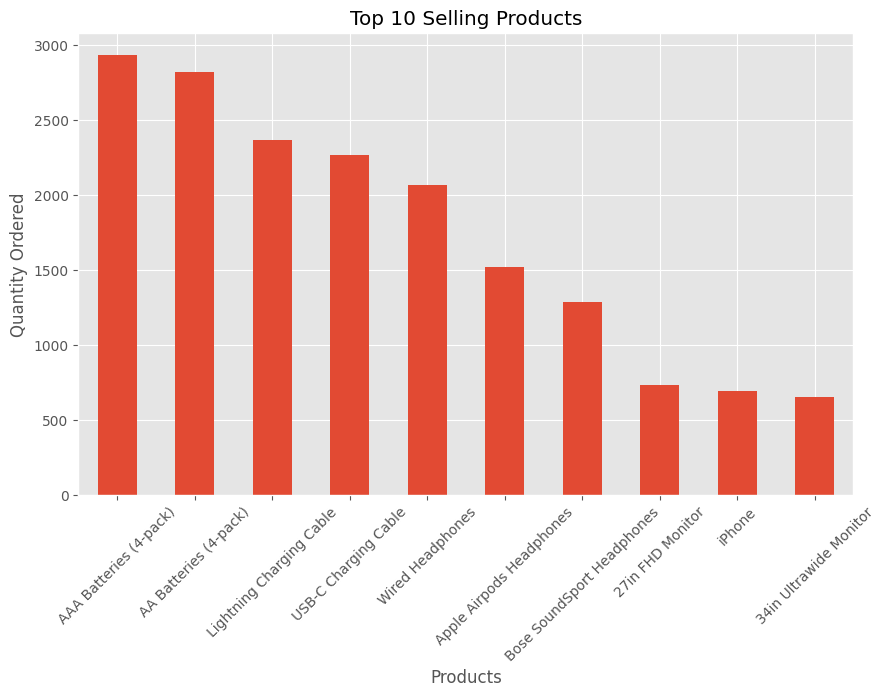

In [26]:
plt.figure(figsize=(10,6))
top_products.head(10).plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Ordered')
plt.xticks(rotation=45)
plt.show()

In [27]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
4    3385499.82
5      10559.29
Name: Sales, dtype: float64

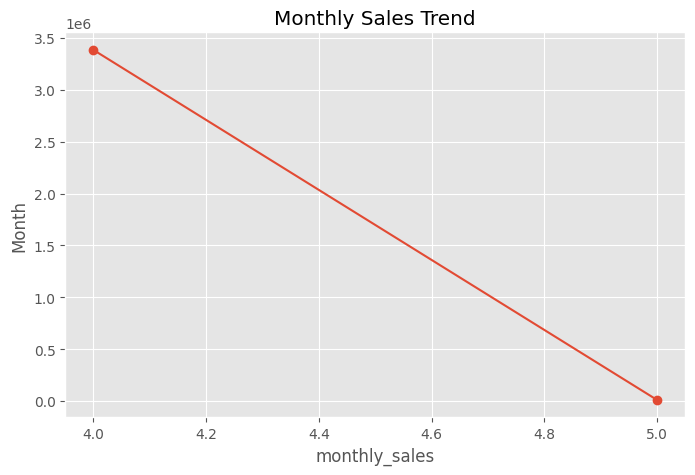

In [28]:
plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('monthly_sales')
plt.ylabel('Month')
plt.show()

In [30]:
city_sales = df.groupby('City')['Sales'].sum().sort_vales(ascending=False)
city_sales

City
San Francisco    817074.77
Los Angeles      551399.07
New York City    446587.78
Boston           353880.16
Atlanta          284454.92
Seattle          276010.24
Dallas           252840.47
Portland         241128.11
Austin           172683.59
Name: Sales, dtype: float64

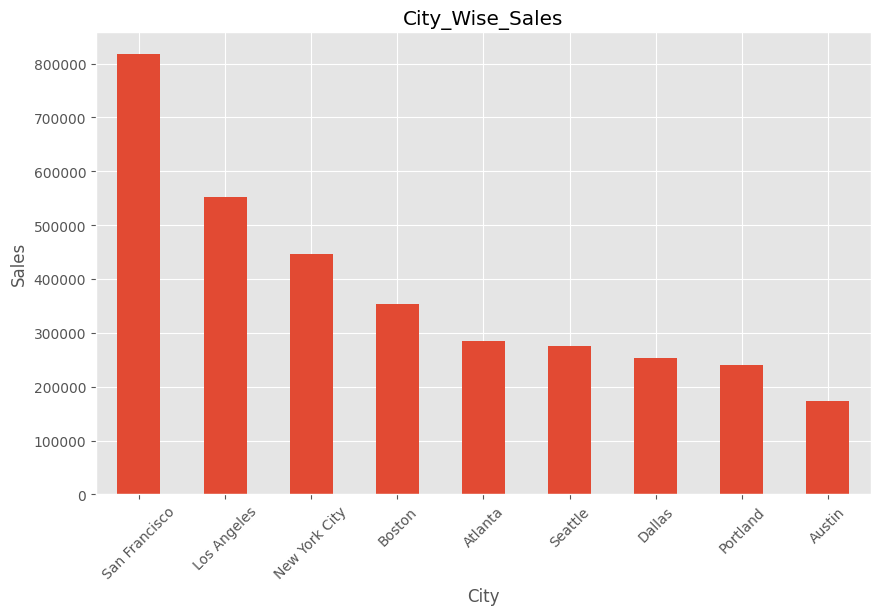

In [32]:
plt.figure(figsize=(10,6))
city_sales.plot(kind='bar')
plt.title('City_Wise_Sales')
plt.xlabel('City')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [34]:
hour_orders = df.groupby('Hour')['Order ID'].sum().sort_values(ascending=False)
hour_orders


Hour
3     1769781775011778311780771782881787171794551794...
6     1766821769001769431769441770421770491770681770...
1     1766481767371768091769071769911770371771711771...
2     1766441768181769451770821772141772541772541774...
5     1766301767121768191768731769761770751771021771...
16    1766051766091766211766391766501766561766661766...
4     1765881766281767881776871779061780941783771786...
21    1765811766141766181766261766411766431766701767...
23    1765781765941766231767001767081767141767351767...
11    1765761765851765851765901766291766631766721766...
0     1765751765801766101766671766761766841767681768...
18    1765731766131766191766311766421766451766641766...
20    1765721765841765961765981766161766221766361766...
15    1765701765991766001766861767401767471767481767...
19    1765691765741765741765771765871766121766251766...
12    1765681765821765831765891766071766081766621766...
17    1765671765861765861766601766891766891767391767...
10    1765641765651765791766041766151766201

In [37]:
print(hour_orders.head())
print(hour_orders.dtypes)
print(type(hour_orders))

Hour
3    1769781775011778311780771782881787171794551794...
6    1766821769001769431769441770421770491770681770...
1    1766481767371768091769071769911770371771711771...
2    1766441768181769451770821772141772541772541774...
5    1766301767121768191768731769761770751771021771...
Name: Order ID, dtype: str
str
<class 'pandas.Series'>


In [38]:
hour_orders = df.groupby('Hour').size()

In [39]:
hour_orders = df.groupby('Hour')['Order ID'].count()

In [40]:
print(hour_orders.head())
print(hour_orders.dtype)

Hour
0    378
1    244
2    132
3     85
4     84
Name: Order ID, dtype: int64
int64


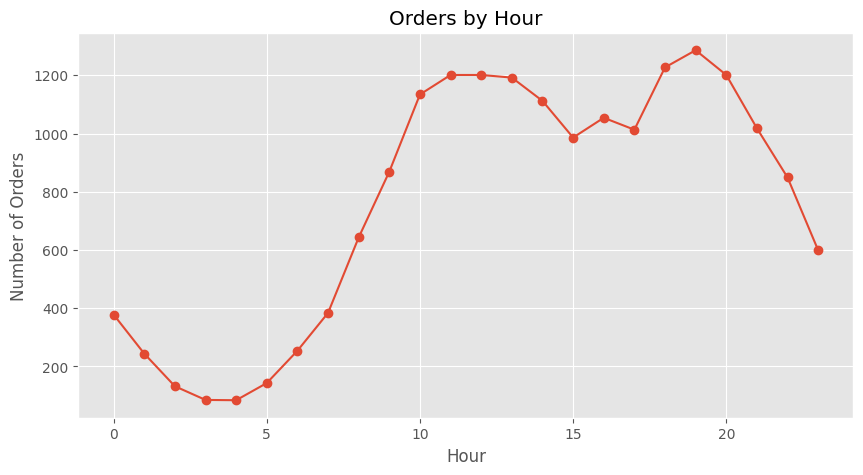

In [41]:
plt.figure(figsize=(10,5))
hour_orders.plot(marker='o')
plt.title('Orders by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.show()

In [42]:
revenue = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
revenue.head(10)

Product
Macbook Pro Laptop            773500.00
iPhone                        486500.00
ThinkPad Laptop               391996.08
Google Phone                  348600.00
34in Ultrawide Monitor        248133.47
Apple Airpods Headphones      228750.00
27in 4K Gaming Monitor        220344.35
Flatscreen TV                 137700.00
Bose SoundSport Headphones    128787.12
27in FHD Monitor              110542.63
Name: Sales, dtype: float64

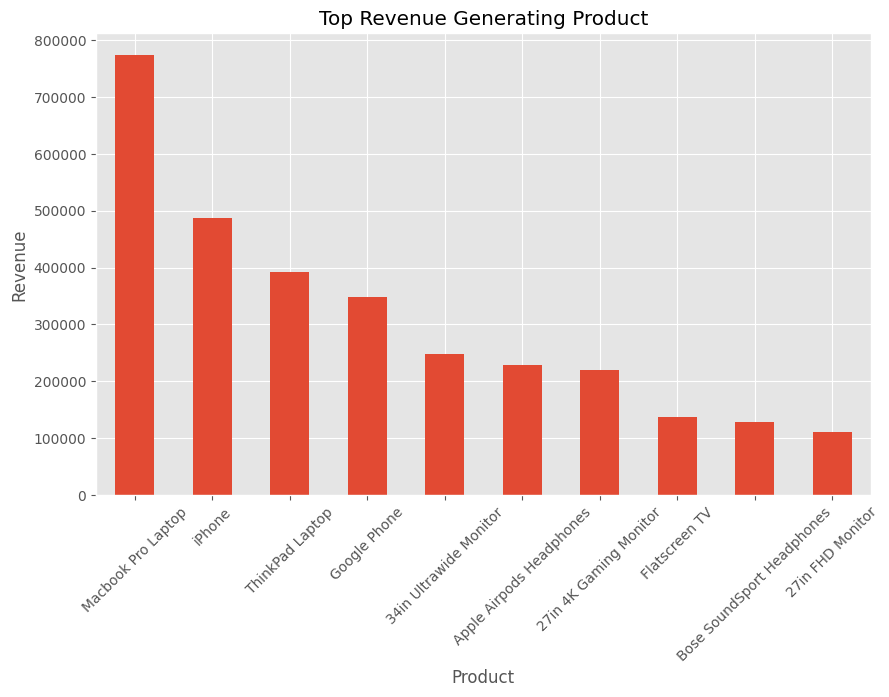

In [44]:
plt.figure(figsize=(10,6))
revenue.head(10).plot(kind='bar')
plt.title('Top Revenue Generating Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


In [49]:
corr = df.select_dtypes(include="number").corr()

corr

,Quantity Ordered,Price Each,Sales,Month,Day,Hour
Quantity Ordered,1.000000,-0.150440,-0.140025,-0.007977,0.000116,-0.005377
Price Each,-0.150440,1.000000,0.997985,0.022785,0.013563,-0.003884
Sales,-0.140025,0.997985,1.000000,0.022563,0.013924,-0.003653
Month,-0.007977,0.022785,0.022563,1.000000,-0.065678,-0.097470
Day,0.000116,0.013563,0.013924,-0.065678,1.000000,0.003041
Hour,-0.005377,-0.003884,-0.003653,-0.097470,0.003041,1.000000


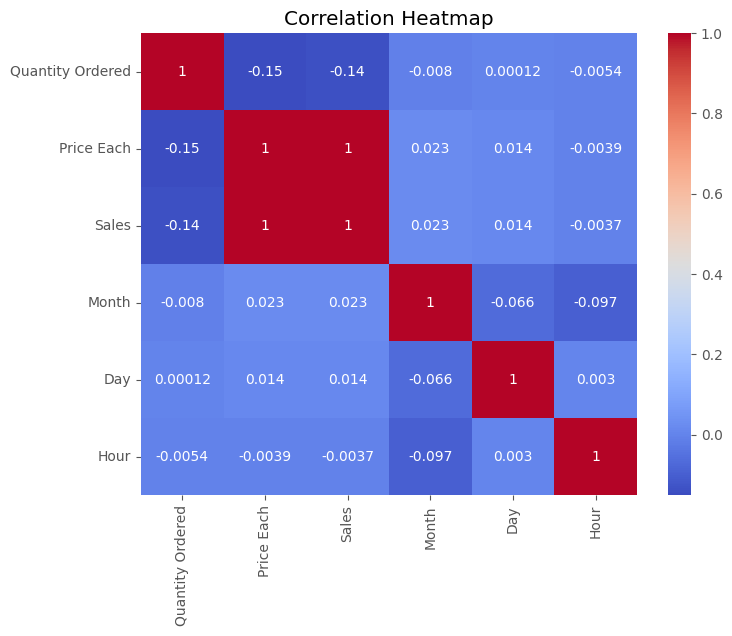

In [50]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

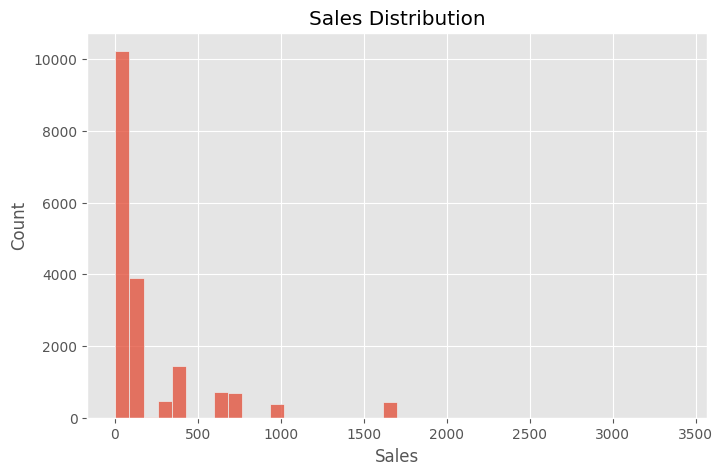

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=40)
plt.title("Sales Distribution")
plt.show()

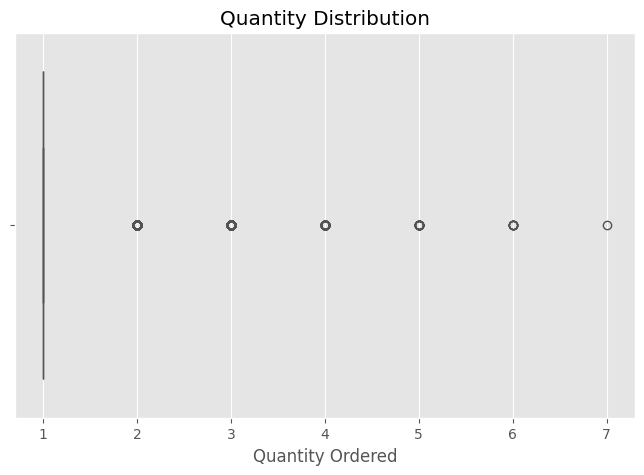

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Quantity Ordered'])
plt.title('Quantity Distribution')
plt.show()
            

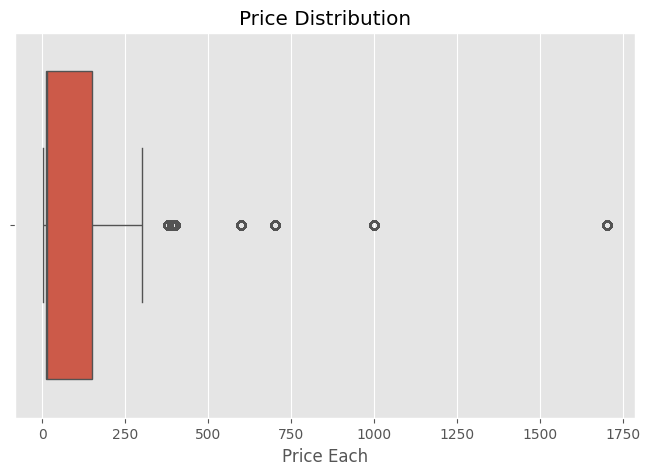

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price Each'])
plt.title('Price Distribution')
plt.show()

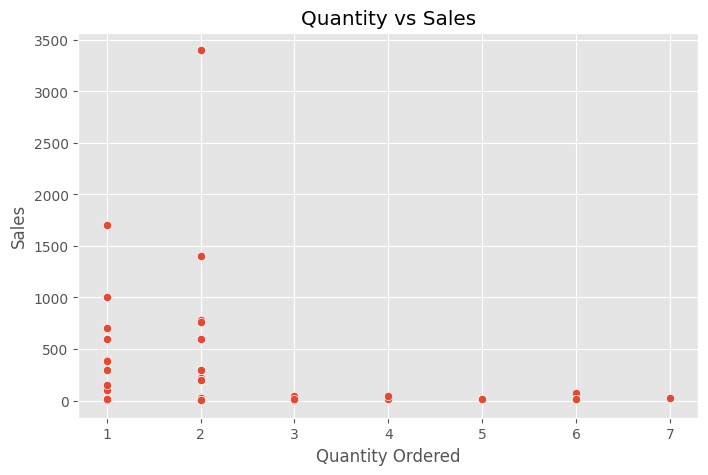

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Quantity Ordered", y="Sales")
plt.title("Quantity vs Sales")
plt.show()

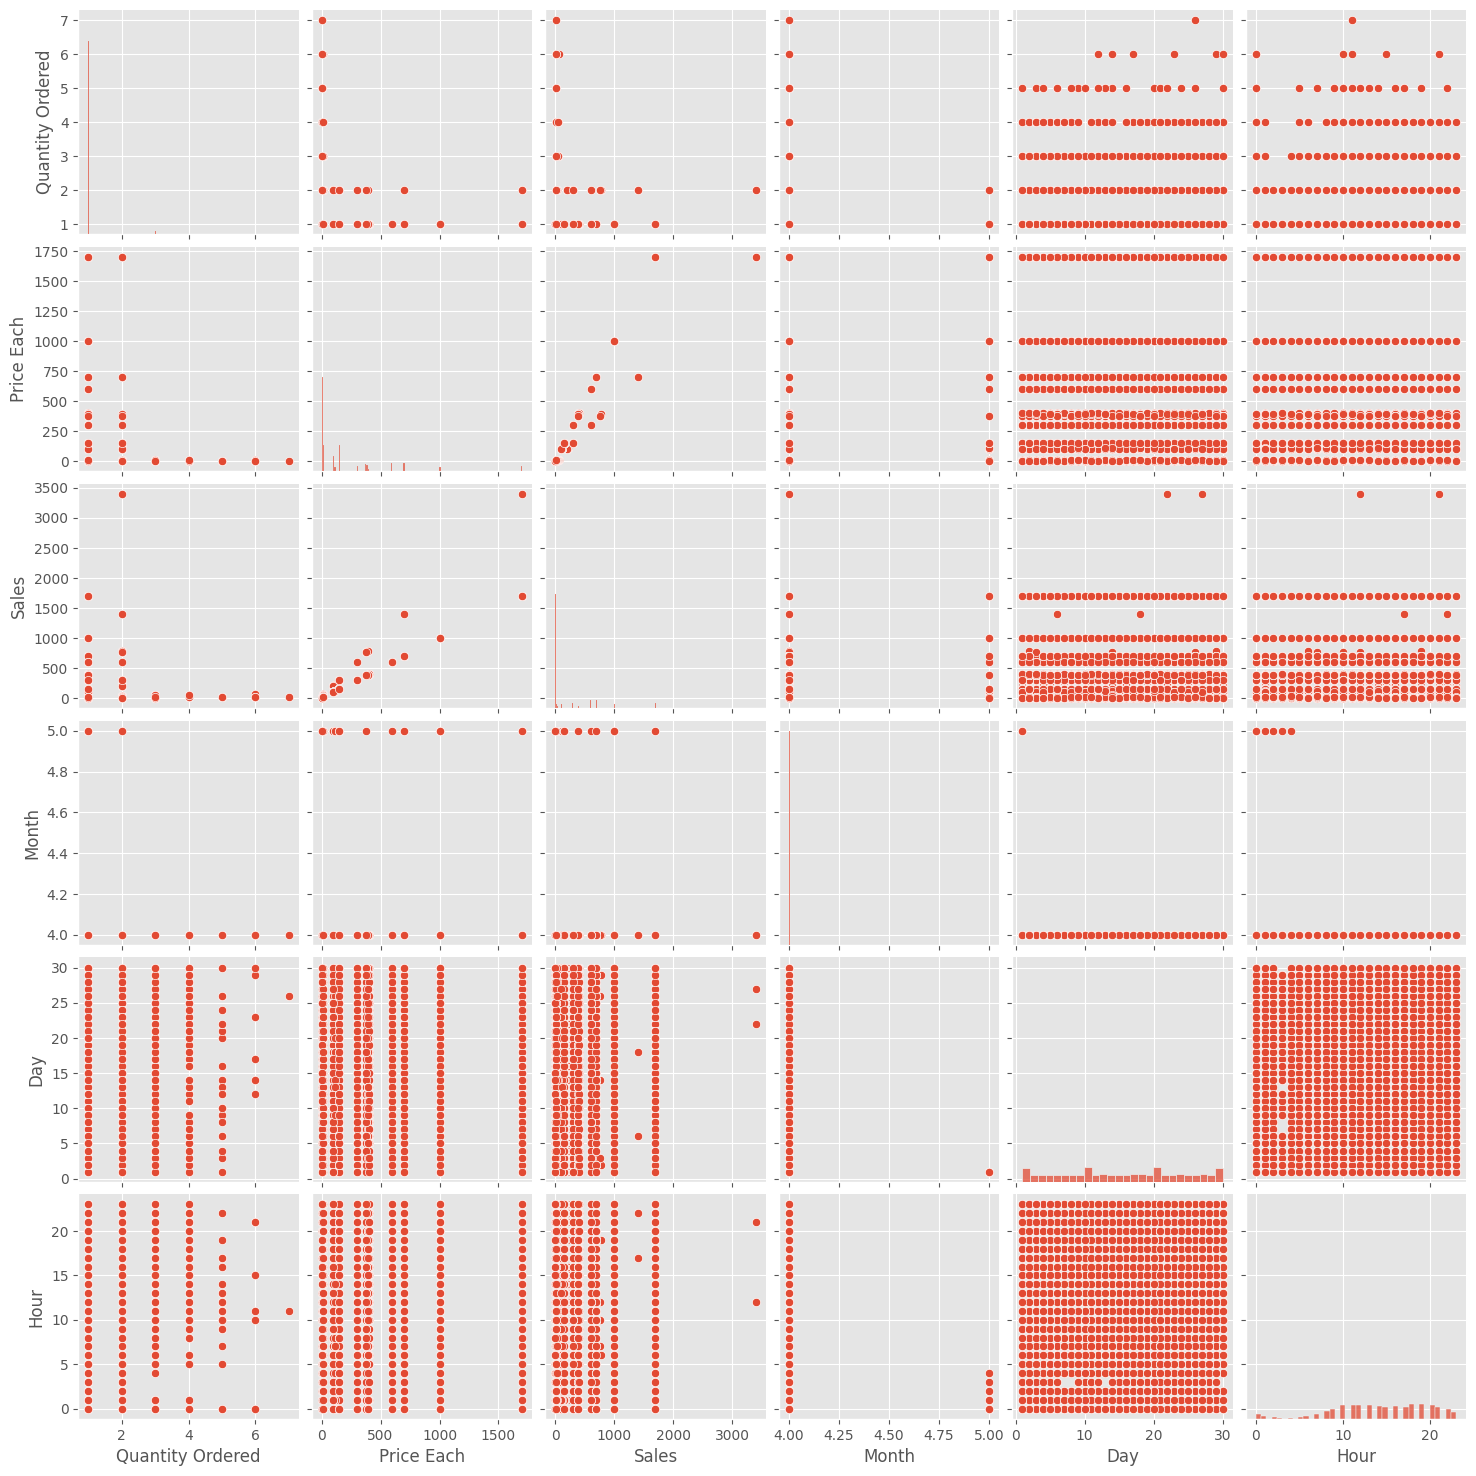

In [56]:
sns.pairplot(df.select_dtypes(include="number"))
plt.show()

Final Insights:
The highest sales were recorded in the month with the maximum revenue.
The city with the highest sales contributed the largest share of revenue.
A few products accounted for most of the sales.
Order volume peaked during specific hours of the day.
Quantity Ordered has a positive relationship with Sales.
Some variables contain outliers, especially Price Each and Sales.
The dataset is suitable for further predictive analysis after cleaning.

In [58]:
import shutil

shutil.copy(
    "Exploratory Data Analysis (EDA).ipnyb",
    r"C:\Users\war\Downloads\Exploratory Data Analysis (EDA).ipnyb"
)

FileNotFoundError: [Errno 2] No such file or directory: 'Exploratory Data Analysis (EDA).ipnyb'